In [1]:
%pip install awscli

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: rsa
    Found existing installation: rsa 4.9.1
    Uninstalling rsa-4.9.1:
      Successfully uninstalled rsa-4.9.1
  Attempting uninstall: docutils
    Found existing installation: docutils 0.21.2
    Uninstalling docutils-0.21.2:
      Successfully uninstalled docutils-0.21.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.


In [2]:
# Criando pastas locais no Colab
zip_path = './data/FlightDelays/'
csv_base_path = './data/csvFlightDelays/'

!mkdir -p {zip_path}
!mkdir -p {csv_base_path}

# Baixando os arquivos da nuvem da AWS
!aws s3 cp s3://aws-tc-largeobjects/CUR-TF-200-ACMLFO-1/flight_delay_project/data/ {zip_path} --recursive --no-sign-request # opção --no-sign-request informa que o download pode ser feito sem autenticação nos servidores da AWS, algo permitido porque o conjunto de dados é público.

download: s3://aws-tc-largeobjects/CUR-TF-200-ACMLFO-1/flight_delay_project/data/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_11.zip to data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_11.zip
download: s3://aws-tc-largeobjects/CUR-TF-200-ACMLFO-1/flight_delay_project/data/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_2.zip to data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_2.zip
download: s3://aws-tc-largeobjects/CUR-TF-200-ACMLFO-1/flight_delay_project/data/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_10.zip to data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_10.zip
download: s3://aws-tc-largeobjects/CUR-TF-200-ACMLFO-1/flight_delay_project/data/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_3.zip to data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_3.zip
download: s3://aws-tc-largeo

In [3]:
import pandas as pd # Importando biblioteca pandas
import zipfile # Importando zip file para garantir a extração de arquivos

path_url = "/content/data/FlightDelays/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2014_1.zip" # Definindo o caminho do arquivo que vamos trabalhar

# Começando a Análise de dados

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Abrir o arquivo zip
with zipfile.ZipFile(path_url, 'r') as zip_ref:
    # Listar os arquivos dentro do zip
    list_files_in_zip = zip_ref.namelist()
    print("Arquivos no ZIP:", list_files_in_zip)
    # Escolhe o primeiro arquivo dentro do Zip
    file_name = list_files_in_zip[0]
    print("Arquivo a ser explorado: ", file_name)
    # Abrir o arquivo específico e ler com Pandas
    with zip_ref.open(file_name) as file_csv:
        df = pd.read_csv(file_csv)

print("Verificando os 5 primeiros valores do Data Frame")
df.head()

Arquivos no ZIP: ['On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2014_1.csv', 'readme.html']
Arquivo a ser explorado:  On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2014_1.csv


/tmp/ipython-input-1183308723.py:14: DtypeWarning: Columns (77,84) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_csv)


Verificando os 5 primeiros valores do Data Frame


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,DestState,DestStateFips,DestStateName,DestWac,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,FirstDepTime,TotalAddGTime,LongestAddGTime,DivAirportLandings,DivReachedDest,DivActualElapsedTime,DivArrDelay,DivDistance,Div1Airport,Div1AirportID,Div1AirportSeqID,Div1WheelsOn,Div1TotalGTime,Div1LongestGTime,Div1WheelsOff,Div1TailNum,Div2Airport,Div2AirportID,Div2AirportSeqID,Div2WheelsOn,Div2TotalGTime,Div2LongestGTime,Div2WheelsOff,Div2TailNum,Div3Airport,Div3AirportID,Div3AirportSeqID,Div3WheelsOn,Div3TotalGTime,Div3LongestGTime,Div3WheelsOff,Div3TailNum,Div4Airport,Div4AirportID,Div4AirportSeqID,Div4WheelsOn,Div4TotalGTime,Div4LongestGTime,Div4WheelsOff,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
0,2014,1,1,30,4,2014-01-30,AA,19805,AA,N006AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,935.0,-5.0,0.0,0.0,-1.0,0900-0959,17.0,952.0,1048.0,3.0,1055,1051.0,-4.0,0.0,0.0,-1.0,1000-1059,0.0,NaN,0.0,75.0,76.0,56.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,1,1,31,5,2014-01-31,AA,19805,AA,N003AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,951.0,11.0,11.0,0.0,0.0,0900-0959,12.0,1003.0,1057.0,18.0,1055,1115.0,20.0,20.0,1.0,1.0,1000-1059,0.0,NaN,0.0,75.0,84.0,54.0,1.0,328.0,2,11.0,0.0,9.0,0.0,0.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014,1,1,1,3,2014-01-01,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1144.0,9.0,9.0,0.0,0.0,1100-1159,12.0,1156.0,1253.0,9.0,1300,1302.0,2.0,2.0,0.0,0.0,1300-1359,0.0,NaN,0.0,85.0,78.0,57.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,1,1,2,4,2014-01-02,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1134.0,-1.0,0.0,0.0,-1.0,1100-1159,11.0,1145.0,1238.0,15.0,1300,1253.0,-7.0,0.0,0.0,-1.0,1300-1359,0.0,NaN,0.0,85.0,79.0,53.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014,1,1,3,5,2014-01-03,AA,19805,AA,N014AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1129.0,-6.0,0.0,0.0,-1.0,1100-1159,12.0,1141.0,1233.0,11.0,1300,1244.0,-16.0,0.0,0.0,-2.0,1300-1359,0.0,NaN,0.0,85.0,75.0,52.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
print("Verificando os 5 últimos valores do Data Frame")
df.tail()

Verificando os 5 últimos valores do Data Frame


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,DestState,DestStateFips,DestStateName,DestWac,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,FirstDepTime,TotalAddGTime,LongestAddGTime,DivAirportLandings,DivReachedDest,DivActualElapsedTime,DivArrDelay,DivDistance,Div1Airport,Div1AirportID,Div1AirportSeqID,Div1WheelsOn,Div1TotalGTime,Div1LongestGTime,Div1WheelsOff,Div1TailNum,Div2Airport,Div2AirportID,Div2AirportSeqID,Div2WheelsOn,Div2TotalGTime,Div2LongestGTime,Div2WheelsOff,Div2TailNum,Div3Airport,Div3AirportID,Div3AirportSeqID,Div3WheelsOn,Div3TotalGTime,Div3LongestGTime,Div3WheelsOff,Div3TailNum,Div4Airport,Div4AirportID,Div4AirportSeqID,Div4WheelsOn,Div4TotalGTime,Div4LongestGTime,Div4WheelsOff,Div4TailNum,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Unnamed: 109
471944,2014,1,1,25,6,2014-01-25,AA,19805,AA,N014AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,937.0,-3.0,0.0,0.0,-1.0,0900-0959,17.0,954.0,1045.0,4.0,1055,1049.0,-6.0,0.0,0.0,-1.0,1000-1059,0.0,NaN,0.0,75.0,72.0,51.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471945,2014,1,1,26,7,2014-01-26,AA,19805,AA,N001AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,935.0,-5.0,0.0,0.0,-1.0,0900-0959,14.0,949.0,1045.0,5.0,1055,1050.0,-5.0,0.0,0.0,-1.0,1000-1059,0.0,NaN,0.0,75.0,75.0,56.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471946,2014,1,1,27,1,2014-01-27,AA,19805,AA,N007AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,937.0,-3.0,0.0,0.0,-1.0,0900-0959,12.0,949.0,1040.0,4.0,1055,1044.0,-11.0,0.0,0.0,-1.0,1000-1059,0.0,NaN,0.0,75.0,67.0,51.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471947,2014,1,1,28,2,2014-01-28,AA,19805,AA,N004AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,959.0,19.0,19.0,1.0,1.0,0900-0959,14.0,1013.0,1103.0,3.0,1055,1106.0,11.0,11.0,0.0,0.0,1000-1059,0.0,NaN,0.0,75.0,67.0,50.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
471948,2014,1,1,29,3,2014-01-29,AA,19805,AA,N006AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,1031.0,51.0,51.0,1.0,3.0,0900-0959,12.0,1043.0,1137.0,3.0,1055,1140.0,45.0,45.0,1.0,3.0,1000-1059,0.0,NaN,0.0,75.0,69.0,54.0,1.0,328.0,2,45.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [6]:
# Verificando o números de Linhas e colunas
df.shape

(471949, 110)

In [7]:
# Verificando Tipos & nulos do nosso Data Set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471949 entries, 0 to 471948
Columns: 110 entries, Year to Unnamed: 109
dtypes: float64(70), int64(21), object(19)
memory usage: 396.1+ MB


In [8]:
# Mostra a soma de valores nulos por coluna
df.isnull().sum()

,0
Year,0
Quarter,0
Month,0
DayofMonth,0
DayOfWeek,0
...,...
Div5TotalGTime,471949
Div5LongestGTime,471949
Div5WheelsOff,471949
Div5TailNum,471949


# Após verificar que existem colunas com todas as linhas em branco, agora é preciso fazer a limpeza

In [9]:
df = df.dropna(axis=1, how='all')
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,DestState,DestStateFips,DestStateName,DestWac,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,Cancelled,CancellationCode,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,FirstDepTime,TotalAddGTime,LongestAddGTime,DivAirportLandings,DivReachedDest,DivActualElapsedTime,DivArrDelay,DivDistance,Div1Airport,Div1AirportID,Div1AirportSeqID,Div1WheelsOn,Div1TotalGTime,Div1LongestGTime,Div1WheelsOff,Div1TailNum,Div2Airport,Div2AirportID,Div2AirportSeqID,Div2WheelsOn,Div2TotalGTime,Div2LongestGTime,Div2WheelsOff,Div2TailNum
0,2014,1,1,30,4,2014-01-30,AA,19805,AA,N006AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,935.0,-5.0,0.0,0.0,-1.0,0900-0959,17.0,952.0,1048.0,3.0,1055,1051.0,-4.0,0.0,0.0,-1.0,1000-1059,0.0,NaN,0.0,75.0,76.0,56.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,1,1,31,5,2014-01-31,AA,19805,AA,N003AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,951.0,11.0,11.0,0.0,0.0,0900-0959,12.0,1003.0,1057.0,18.0,1055,1115.0,20.0,20.0,1.0,1.0,1000-1059,0.0,NaN,0.0,75.0,84.0,54.0,1.0,328.0,2,11.0,0.0,9.0,0.0,0.0,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014,1,1,1,3,2014-01-01,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1144.0,9.0,9.0,0.0,0.0,1100-1159,12.0,1156.0,1253.0,9.0,1300,1302.0,2.0,2.0,0.0,0.0,1300-1359,0.0,NaN,0.0,85.0,78.0,57.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,1,1,2,4,2014-01-02,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1134.0,-1.0,0.0,0.0,-1.0,1100-1159,11.0,1145.0,1238.0,15.0,1300,1253.0,-7.0,0.0,0.0,-1.0,1300-1359,0.0,NaN,0.0,85.0,79.0,53.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014,1,1,3,5,2014-01-03,AA,19805,AA,N014AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1129.0,-6.0,0.0,0.0,-1.0,1100-1159,12.0,1141.0,1233.0,11.0,1300,1244.0,-16.0,0.0,0.0,-2.0,1300-1359,0.0,NaN,0.0,85.0,75.0,52.0,1.0,328.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Verificando novamente quantas colunas e linhas tem o nosso DataFrame

In [10]:
df.shape

(471949, 85)

# Verificando a porcetagem de valores nulos do nosso Data Frame


In [11]:
percentage_nulls = (df.isnull().sum() / len(df)) * 100
print(f'Porcentagem de valores nulos: {percentage_nulls}')

Porcentagem de valores nulos: Year                                0.000000
Quarter                             0.000000
Month                               0.000000
DayofMonth                          0.000000
DayOfWeek                           0.000000
FlightDate                          0.000000
Reporting_Airline                   0.000000
DOT_ID_Reporting_Airline            0.000000
IATA_CODE_Reporting_Airline         0.000000
Tail_Number                         0.857296
Flight_Number_Reporting_Airline     0.000000
OriginAirportID                     0.000000
OriginAirportSeqID                  0.000000
OriginCityMarketID                  0.000000
Origin                              0.000000
OriginCityName                      0.000000
OriginState                         0.000000
OriginStateFips                     0.000000
OriginStateName                     0.000000
OriginWac                           0.000000
DestAirportID                       0.000000
DestAirportSeqID         

# Removendo valores com base em uma condição
Após verificar a porcentagem de dados que estão nulos, agora é preciso remover colunas que tenha mais de **95% das linhas com valor nulo.**

**Condição**: remover colunas que tenha mais de 95% das linhas com valor nulo.

Usando `.all()` para verificar se todos os valores em uma coluna `(eixo 0)` satisfazem a condição.

In [12]:
mask = percentage_nulls > 95 # aplicando a máscara
columns_to_remove = df.columns[mask]
# Código a seguir serve para ver quais são as colunas para ser excluidos antes de executar
print("Colunas que serão removidas:", list(columns_to_remove))
df = df.drop(columns=columns_to_remove)

Colunas que serão removidas: ['FirstDepTime', 'TotalAddGTime', 'LongestAddGTime', 'DivReachedDest', 'DivActualElapsedTime', 'DivArrDelay', 'DivDistance', 'Div1Airport', 'Div1AirportID', 'Div1AirportSeqID', 'Div1WheelsOn', 'Div1TotalGTime', 'Div1LongestGTime', 'Div1WheelsOff', 'Div1TailNum', 'Div2Airport', 'Div2AirportID', 'Div2AirportSeqID', 'Div2WheelsOn', 'Div2TotalGTime', 'Div2LongestGTime', 'Div2WheelsOff', 'Div2TailNum']


# Verificando os nulos restantes (somente os maiores que zero para facilitar a leitura)

In [13]:
nulos_restantes = df.isnull().sum()
print(nulos_restantes[nulos_restantes > 0])

Tail_Number               4046
DepTime                  30327
DepDelay                 30327
DepDelayMinutes          30327
DepDel15                 30327
DepartureDelayGroups     30327
TaxiOut                  30683
WheelsOff                30683
WheelsOn                 31496
TaxiIn                   31496
ArrTime                  31496
ArrDelay                 32329
ArrDelayMinutes          32329
ArrDel15                 32329
ArrivalDelayGroups       32329
CancellationCode        441097
ActualElapsedTime        32329
AirTime                  32329
CarrierDelay            351955
WeatherDelay            351955
NASDelay                351955
SecurityDelay           351955
LateAircraftDelay       351955
dtype: int64


### Como queremos analisar o nosso dataframe focando em analises de atrasos em voos. Vamos remover todos os valores que são nulos, pois percebe se que voos que o avião não saiu do chão não foi preenchido, assim fazendo mais sentido remover para analisar apenas os dados não nulos.

In [14]:
# Remove linhas onde a coluna 'DepTime'(Tempo de voo) está vazia
df = df.dropna(subset=['DepTime'])

In [15]:
df.shape

(441622, 62)

In [16]:
# Remove linhas onde não sabemos o atraso na chegada
df = df.dropna(subset=['ArrDelay'])

In [17]:
nulos_restantes = df.isnull().sum()
print(nulos_restantes[nulos_restantes > 0])

CancellationCode     439620
CarrierDelay         319626
WeatherDelay         319626
NASDelay             319626
SecurityDelay        319626
LateAircraftDelay    319626
dtype: int64


**Preenchendo as seguintes colunas com o valor 0 ao invès do valor Nulo:**
- de Código de cancelamento;
- Atraso da transportadora;
- Atraso devido ao clima;
- Atraso da NAS;
- Atraso de segurança;
- Atraso da aeronave.

In [18]:
# Lista das colunas de motivos de atraso
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

# Preenche os nulos dessas colunas com 0
df[delay_cols] = df[delay_cols].fillna(0)

In [19]:
# Remove a coluna CancellationCode
if 'CancellationCode' in df.columns:
    df = df.drop(columns=['CancellationCode'])

# Após a limpeza, diminuiu para 61 colunas

In [20]:
df.shape

(439620, 61)

## Depois de rodar os blocos de  código anterios, veremos se ainda tem valores nulos no nosso DataFrame

In [21]:
df.isnull().sum().sum()

np.int64(0)

In [22]:
df.head() # Verificando o nosso DataFrame

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,DestState,DestStateFips,DestStateName,DestWac,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,Cancelled,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DivAirportLandings
0,2014,1,1,30,4,2014-01-30,AA,19805,AA,N006AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,935.0,-5.0,0.0,0.0,-1.0,0900-0959,17.0,952.0,1048.0,3.0,1055,1051.0,-4.0,0.0,0.0,-1.0,1000-1059,0.0,0.0,75.0,76.0,56.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0
1,2014,1,1,31,5,2014-01-31,AA,19805,AA,N003AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,951.0,11.0,11.0,0.0,0.0,0900-0959,12.0,1003.0,1057.0,18.0,1055,1115.0,20.0,20.0,1.0,1.0,1000-1059,0.0,0.0,75.0,84.0,54.0,1.0,328.0,2,11.0,0.0,9.0,0.0,0.0,0
2,2014,1,1,1,3,2014-01-01,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1144.0,9.0,9.0,0.0,0.0,1100-1159,12.0,1156.0,1253.0,9.0,1300,1302.0,2.0,2.0,0.0,0.0,1300-1359,0.0,0.0,85.0,78.0,57.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0
3,2014,1,1,2,4,2014-01-02,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1134.0,-1.0,0.0,0.0,-1.0,1100-1159,11.0,1145.0,1238.0,15.0,1300,1253.0,-7.0,0.0,0.0,-1.0,1300-1359,0.0,0.0,85.0,79.0,53.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0
4,2014,1,1,3,5,2014-01-03,AA,19805,AA,N014AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1129.0,-6.0,0.0,0.0,-1.0,1100-1159,12.0,1141.0,1233.0,11.0,1300,1244.0,-16.0,0.0,0.0,-2.0,1300-1359,0.0,0.0,85.0,75.0,52.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0


In [23]:
df.info() # Verificando novamente os dados e tipos

<class 'pandas.core.frame.DataFrame'>
Index: 439620 entries, 0 to 471948
Data columns (total 61 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Year                             439620 non-null  int64  
 1   Quarter                          439620 non-null  int64  
 2   Month                            439620 non-null  int64  
 3   DayofMonth                       439620 non-null  int64  
 4   DayOfWeek                        439620 non-null  int64  
 5   FlightDate                       439620 non-null  object 
 6   Reporting_Airline                439620 non-null  object 
 7   DOT_ID_Reporting_Airline         439620 non-null  int64  
 8   IATA_CODE_Reporting_Airline      439620 non-null  object 
 9   Tail_Number                      439620 non-null  object 
 10  Flight_Number_Reporting_Airline  439620 non-null  int64  
 11  OriginAirportID                  439620 non-null  int64  
 12  OriginA

## Convertendo as datas para o formato datetime

In [24]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
print(f"Tipo novo: {df['FlightDate'].dtype}")
df.head()

Tipo novo: datetime64[ns]


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,DestState,DestStateFips,DestStateName,DestWac,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,Cancelled,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DivAirportLandings
0,2014,1,1,30,4,2014-01-30,AA,19805,AA,N006AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,935.0,-5.0,0.0,0.0,-1.0,0900-0959,17.0,952.0,1048.0,3.0,1055,1051.0,-4.0,0.0,0.0,-1.0,1000-1059,0.0,0.0,75.0,76.0,56.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0
1,2014,1,1,31,5,2014-01-31,AA,19805,AA,N003AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,951.0,11.0,11.0,0.0,0.0,0900-0959,12.0,1003.0,1057.0,18.0,1055,1115.0,20.0,20.0,1.0,1.0,1000-1059,0.0,0.0,75.0,84.0,54.0,1.0,328.0,2,11.0,0.0,9.0,0.0,0.0,0
2,2014,1,1,1,3,2014-01-01,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1144.0,9.0,9.0,0.0,0.0,1100-1159,12.0,1156.0,1253.0,9.0,1300,1302.0,2.0,2.0,0.0,0.0,1300-1359,0.0,0.0,85.0,78.0,57.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0
3,2014,1,1,2,4,2014-01-02,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1134.0,-1.0,0.0,0.0,-1.0,1100-1159,11.0,1145.0,1238.0,15.0,1300,1253.0,-7.0,0.0,0.0,-1.0,1300-1359,0.0,0.0,85.0,79.0,53.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0
4,2014,1,1,3,5,2014-01-03,AA,19805,AA,N014AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1129.0,-6.0,0.0,0.0,-1.0,1100-1159,12.0,1141.0,1233.0,11.0,1300,1244.0,-16.0,0.0,0.0,-2.0,1300-1359,0.0,0.0,85.0,75.0,52.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0


# Extraindo hora do horário de partida

In [25]:
# Criando a coluna de Hora de Partida (DepHour) para o nosso DataFrame
df['DepHour'] = df['DepTime'].astype(int) // 100

# Vamos conferir se funcionou vendo os valores únicos ordenados
print(sorted(df['DepHour'].unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


In [26]:
valores_unicos = df['DepHour'].to_list()

print(f"Valores únicos: {valores_unicos}")

Valores únicos: [9, 9, 11, 11, 11, 11, 11, 12, 12, 11, 13, 11, 11, 11, 11, 11, 11, 12, 12, 11, 11, 11, 12, 11, 11, 11, 11, 11, 11, 11, 12, 11, 11, 22, 23, 22, 23, 23, 23, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 23, 22, 22, 22, 10, 11, 15, 9, 11, 19, 23, 15, 14, 6, 12, 7, 16, 10, 15, 6, 15, 7, 11, 10, 14, 7, 18, 8, 8, 12, 18, 16, 13, 14, 15, 22, 8, 22, 17, 22, 12, 6, 9, 16, 15, 9, 23, 7, 14, 18, 8, 18, 13, 9, 9, 7, 21, 9, 6, 8, 18, 18, 19, 7, 18, 8, 15, 12, 8, 8, 6, 17, 13, 18, 10, 12, 18, 20, 6, 8, 14, 16, 18, 17, 19, 21, 7, 6, 9, 11, 13, 15, 13, 13, 5, 14, 17, 19, 8, 10, 15, 16, 16, 14, 18, 5, 8, 16, 13, 15, 16, 22, 21, 0, 18, 20, 11, 12, 7, 21, 23, 0, 23, 20, 10, 1, 19, 2, 9, 8, 19, 11, 1, 12, 9, 16, 19, 18, 9, 6, 17, 8, 6, 7, 9, 11, 13, 15, 16, 17, 22, 5, 17, 7, 20, 20, 10, 6, 17, 20, 9, 20, 7, 7, 17, 21, 18, 13, 17, 19, 12, 15, 17, 9, 14, 9, 6, 6, 12, 15, 7, 7, 15, 5, 9, 6, 18, 12, 21, 9, 6, 21, 11, 19, 18, 6, 19, 7, 5, 8, 5, 19, 21, 17, 9, 7, 10, 14, 21, 16, 20, 6, 19, 19, 5, 7, 1

In [27]:
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,DestState,DestStateFips,DestStateName,DestWac,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,Cancelled,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DivAirportLandings,DepHour
0,2014,1,1,30,4,2014-01-30,AA,19805,AA,N006AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,935.0,-5.0,0.0,0.0,-1.0,0900-0959,17.0,952.0,1048.0,3.0,1055,1051.0,-4.0,0.0,0.0,-1.0,1000-1059,0.0,0.0,75.0,76.0,56.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0,9
1,2014,1,1,31,5,2014-01-31,AA,19805,AA,N003AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,951.0,11.0,11.0,0.0,0.0,0900-0959,12.0,1003.0,1057.0,18.0,1055,1115.0,20.0,20.0,1.0,1.0,1000-1059,0.0,0.0,75.0,84.0,54.0,1.0,328.0,2,11.0,0.0,9.0,0.0,0.0,0,9
2,2014,1,1,1,3,2014-01-01,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1144.0,9.0,9.0,0.0,0.0,1100-1159,12.0,1156.0,1253.0,9.0,1300,1302.0,2.0,2.0,0.0,0.0,1300-1359,0.0,0.0,85.0,78.0,57.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0,11
3,2014,1,1,2,4,2014-01-02,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1134.0,-1.0,0.0,0.0,-1.0,1100-1159,11.0,1145.0,1238.0,15.0,1300,1253.0,-7.0,0.0,0.0,-1.0,1300-1359,0.0,0.0,85.0,79.0,53.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0,11
4,2014,1,1,3,5,2014-01-03,AA,19805,AA,N014AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1129.0,-6.0,0.0,0.0,-1.0,1100-1159,12.0,1141.0,1233.0,11.0,1300,1244.0,-16.0,0.0,0.0,-2.0,1300-1359,0.0,0.0,85.0,75.0,52.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0,11


## Com as horas exportada, vamos definir que o tempo de atraso será de **15 minutos** após ou antes da hora marcado

- Vamos focar o nosso minuto de atraso olhando para a coluna **ArrDelay** *(Atraso na Chegada em minutos).*
- Criando uma coluna de minutos de atraso (mantendo 0 quando não há atraso)
- Criando uma **flag 0 para quando não houve** atraso e **1 para quando houve atraso**
- Criar coluna com o valor absoluto do atraso

In [28]:
# mantém os minutos de atraso quando > 15, senão 0
df['atraso'] = df['ArrDelay'].where(df['ArrDelay'] > 15, 0)
# Isso mostra a diferença do horário previsto, independente se foi antes ou depois
df['ArrDelayAbs'] = df['ArrDelay'].abs()

df['flag_atraso'] = (df['atraso'] > 0).astype(int)

In [29]:
df.head()

,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,Origin,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,Dest,DestCityName,DestState,DestStateFips,DestStateName,DestWac,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,ArrDelay,ArrDelayMinutes,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,Cancelled,Diverted,CRSElapsedTime,ActualElapsedTime,AirTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DivAirportLandings,DepHour,atraso,ArrDelayAbs,flag_atraso
0,2014,1,1,30,4,2014-01-30,AA,19805,AA,N006AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,935.0,-5.0,0.0,0.0,-1.0,0900-0959,17.0,952.0,1048.0,3.0,1055,1051.0,-4.0,0.0,0.0,-1.0,1000-1059,0.0,0.0,75.0,76.0,56.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0,9,0.0,4.0,0
1,2014,1,1,31,5,2014-01-31,AA,19805,AA,N003AA,2377,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,940,951.0,11.0,11.0,0.0,0.0,0900-0959,12.0,1003.0,1057.0,18.0,1055,1115.0,20.0,20.0,1.0,1.0,1000-1059,0.0,0.0,75.0,84.0,54.0,1.0,328.0,2,11.0,0.0,9.0,0.0,0.0,0,9,20.0,20.0,1
2,2014,1,1,1,3,2014-01-01,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1144.0,9.0,9.0,0.0,0.0,1100-1159,12.0,1156.0,1253.0,9.0,1300,1302.0,2.0,2.0,0.0,0.0,1300-1359,0.0,0.0,85.0,78.0,57.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0,11,0.0,2.0,0
3,2014,1,1,2,4,2014-01-02,AA,19805,AA,N002AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1134.0,-1.0,0.0,0.0,-1.0,1100-1159,11.0,1145.0,1238.0,15.0,1300,1253.0,-7.0,0.0,0.0,-1.0,1300-1359,0.0,0.0,85.0,79.0,53.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0,11,0.0,7.0,0
4,2014,1,1,3,5,2014-01-03,AA,19805,AA,N014AA,2377,12278,1227802,30928,ICT,"Wichita, KS",KS,20,Kansas,62,11298,1129803,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,1135,1129.0,-6.0,0.0,0.0,-1.0,1100-1159,12.0,1141.0,1233.0,11.0,1300,1244.0,-16.0,0.0,0.0,-2.0,1300-1359,0.0,0.0,85.0,75.0,52.0,1.0,328.0,2,0.0,0.0,0.0,0.0,0.0,0,11,0.0,16.0,0


In [30]:
mean_delay = df['flag_atraso'].mean()
print(f"Média de atrasos por voo: {(mean_delay * 100):.2f}%")

Média de atrasos por voo: 26.43%


Com o dado de 26,43% do voo atrasam então basicamente **1 em cada 4 voos atrasa mais de 15 minutos**. Assim se fosse para mostrar para um gerente de aeroporto já saberia que mais 25% da sua operação tem problemas graves de atraso.

# Depois analisar e limpar os dados vamos importar a biblioteca as bibliotecas gráficas (matplotlib.pyplot e seaborn)

- Para visualizarmos histograma de atrasos (DepDelay)

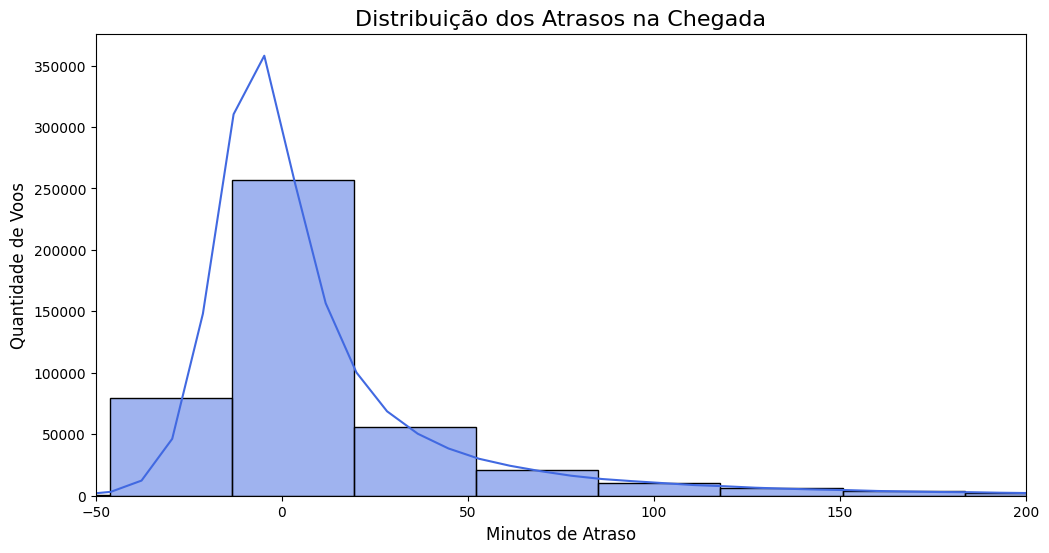

In [31]:
# Importando as bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho da figura
plt.figure(figsize=(12, 6))

# Usando o Seaborn (histplot) com a linha de densidade (kde=True)
sns.histplot(data=df, x='ArrDelay', bins=50, kde=True, color='royalblue')

# Títulos e legendas
plt.title('Distribuição dos Atrasos na Chegada', fontsize=16)
plt.xlabel('Minutos de Atraso', fontsize=12)
plt.ylabel('Quantidade de Voos', fontsize=12)

# Limitando o eixo X para focar onde a maioria dos dados está
plt.xlim(-50, 200)

# Mostra o gráfico
plt.show()


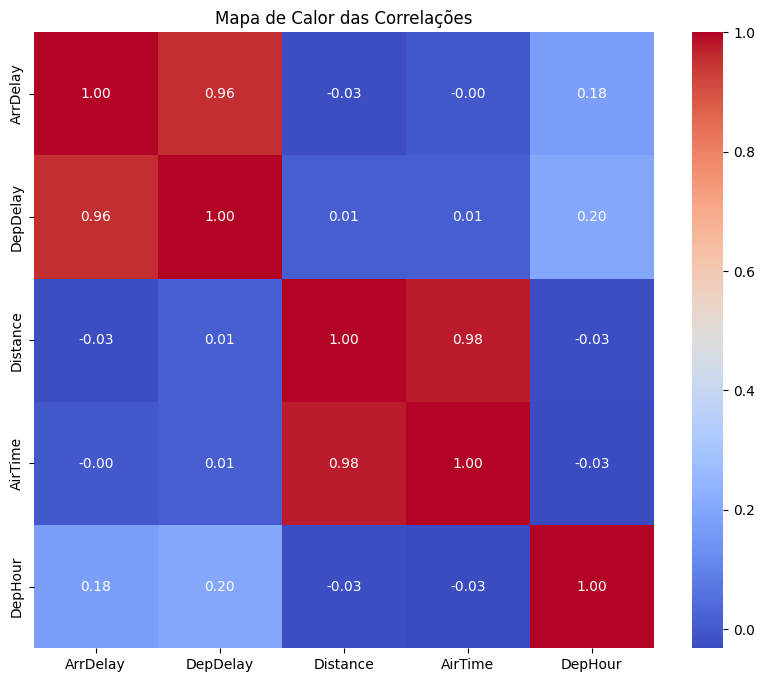

In [32]:
plt.figure(figsize=(10, 8))

# Selecionando apenas colunas numéricas relevantes para correlação
cols_corr = ['ArrDelay', 'DepDelay', 'Distance', 'AirTime', 'DepHour']
correlacao = df[cols_corr].corr()

# Criando o Heatmap
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor das Correlações')
plt.show()

O heatmap valida a consistência dos dados (correlação Distância/Tempo) e aponta o gargalo operacional crítico: a forte correlação (0.96) entre partida(DepDelay) e chegada(ArrDelay) prova que a pontualidade depende quase exclusivamente da eficiência das operações em solo

# Fazendo o Boxplot (Visualização de Outliers)

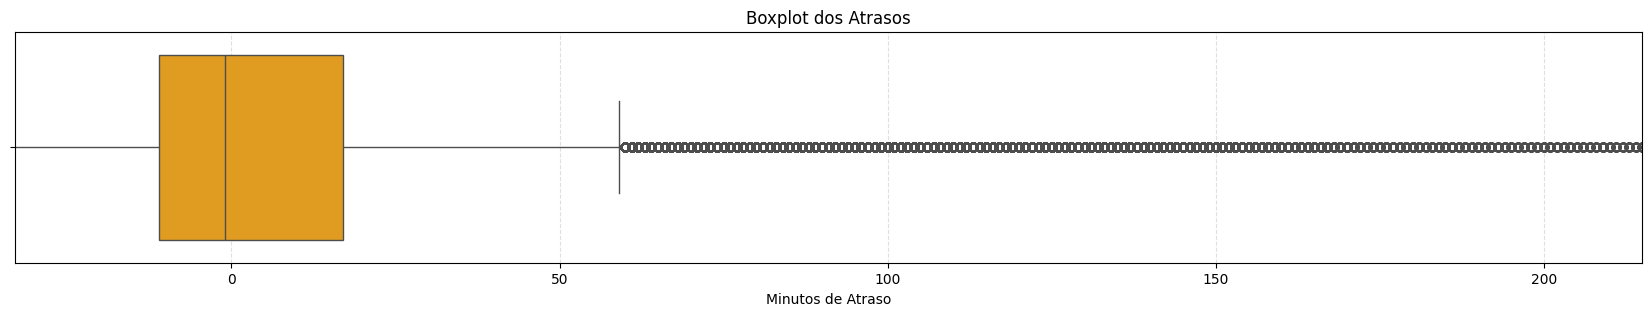

In [38]:
plt.figure(figsize=(21, 3))

# limitar visualmente pelos percentis para diminuir o impacto dos outliers
p1, p99 = df['ArrDelay'].quantile([0.01, 0.99])

sns.boxplot(x=df['ArrDelay'], color='orange')
plt.title('Boxplot dos Atrasos')
plt.xlabel('Minutos de Atraso')
plt.xlim(p1, p99)   # zoom automático baseado nos dados

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

/tmp/ipython-input-1635188289.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_airports.values, y=top_airports.index, palette='Reds_r')


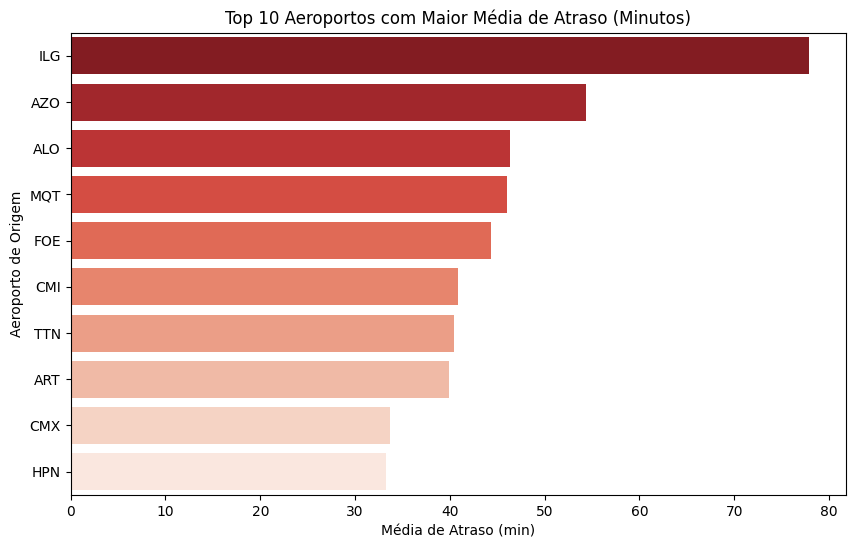

In [34]:
# Agrupa por aeroporto de origem e calcula a média de atraso
top_airports = df.groupby('Origin')['ArrDelay'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_airports.values, y=top_airports.index, palette='Reds_r')
plt.title('Top 10 Aeroportos com Maior Média de Atraso (Minutos)')
plt.xlabel('Média de Atraso (min)')
plt.ylabel('Aeroporto de Origem')
plt.show()

# Salvando o arquivo limpo em formato .csv

In [35]:
# Salvando o arquivo limpo para não perder o trabalho
# index=False garante que não vamos salvar aquela coluna de números 0, 1, 2... extra
df.to_csv('flight_delays_clean.csv', index=False)

print("Arquivo 'flight_delays_clean.csv' salvo com sucesso!")

Arquivo 'flight_delays_clean.csv' salvo com sucesso!


# Fazendo analises de correlações da dados
- Pode se observar que o **tempo de chegada** `(ArrDelay)` de **96%** de correlação com com o **tempo de partida**`(DepDelay)`
- O tempo de voo no ar é 98% de correlação com a distancia entre os voos

## Conclusões e Insights do Desafio

Após a análise exploratória dos dados de voos, destacamos os seguintes pontos:

- **Problema Crítico de Pontualidade:** 26,43% dos voos analisados atrasaram mais de 15 minutos, um índice elevado que impacta a experiência do cliente.
- **A Raiz do Problema está na Origem:** A correlação quase perfeita (0.96) entre atraso na partida e na chegada confirma que atrasos em solo não são recuperados durante o voo.
- **Limpeza de Dados:** A base continha colunas inteiramente vazias (ex: `Unnamed: 109`) e registros de voos cancelados que precisaram ser removidos para garantir a precisão das métricas de atraso.

- **Gargalos Geográficos (Top 10 Aeroportos):**
A análise por aeroporto de origem identificou quais terminais apresentam as maiores médias de atraso.
- **Ação Recomendada:** Focar esforços operacionais e ajustes de malha especificamente nestes 10 aeroportos críticos para reduzir a média global de atrasos da companhia.

- **Impacto dos "Outliers" (Valores Extremos):**
O *Boxplot* revelou a existência de valores discrepantes (*outliers*) significativos.
Embora a mediana dos atrasos seja baixa, existem voos pontuais com atrasos extremos (acima de 200-300 minutos) que elevam a média e causam danos severos à reputação da marca, exigindo planos de contingência específicos.

- **Precisão do Planeamento (Atraso Absoluto):**
Ao calcular o `ArrDelayAbs`, observamos a magnitude real do erro de planeamento (seja atraso ou adiantamento). Isso ajuda a medir a confiabilidade da escala, independentemente da direção do erro.